# Task 1
Tom

## Can the series be grouped?

To answer this we look at the **returns** (since price levels are non-stationary and on different scales) from three angles:

1. The return correlation matrix — which series move together?
2. Return volatility — how big are the daily moves for each series?
3. A simple visual check on the correlation matrix to confirm the groups.

In [5]:
# Load data and clean the 1000-anomaly the same way as in cell 1 and cell 2 above
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_clean = pd.read_csv("../augmented_data/spiff_data_cleaned.csv", index_col="day")

# work with returns
returns = data_clean.pct_change().dropna()
print("Number of return observations:", len(returns))

Number of return observations: 4898


### Correlation matrix of returns

We already saw the correlation matrix in the section above. Let's reprint it here so we can read off the grouping directly.

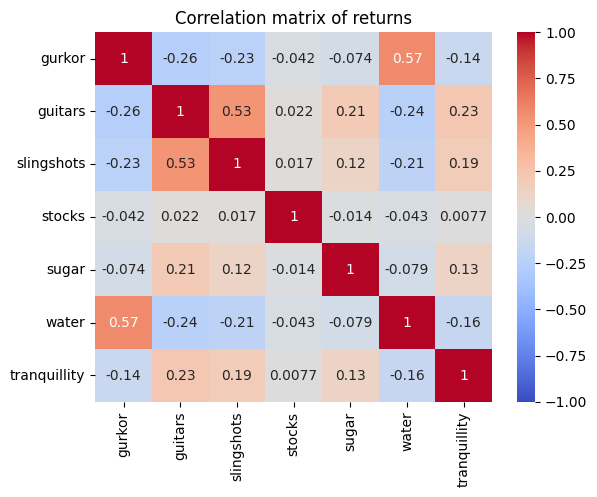

              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor          1.00    -0.26       -0.23   -0.04  -0.07   0.57         -0.14
guitars        -0.26     1.00        0.53    0.02   0.21  -0.24          0.23
slingshots     -0.23     0.53        1.00    0.02   0.12  -0.21          0.19
stocks         -0.04     0.02        0.02    1.00  -0.01  -0.04          0.01
sugar          -0.07     0.21        0.12   -0.01   1.00  -0.08          0.13
water           0.57    -0.24       -0.21   -0.04  -0.08   1.00         -0.16
tranquillity   -0.14     0.23        0.19    0.01   0.13  -0.16          1.00


In [6]:
import seaborn as sns

corrmat = returns.corr()
sns.heatmap(corrmat, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation matrix of returns")
plt.show()

print(corrmat.round(2))

Reading the matrix:

* `gurkor` and `water` are positively correlated (~+0.57) and negatively correlated with most of the others.
* `guitars`, `slingshots`, `sugar`, `tranquillity` are positively correlated with each other.
* `stocks` has near-zero correlation with everything (all values within ±0.05).

### Return volatility

Looking at the size of daily moves should also tell us something — series in the same group tend to have similar volatility.

Daily return std:
water           0.00343
gurkor          0.00385
tranquillity    0.01231
slingshots      0.01439
guitars         0.01458
stocks          0.01459
sugar           0.01486
dtype: float64


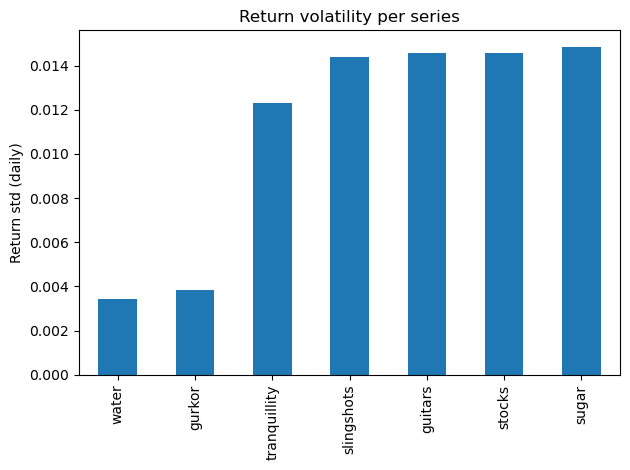

In [26]:
# daily return std for each series, sorted
vol = returns.std().sort_values()
print("Daily return std:")
print(vol.round(5))

vol.plot(kind='bar')
plt.ylabel("Return std (daily)")
plt.title("Return volatility per series")
plt.tight_layout()
plt.show()

### Conclusion: three groups

Both the correlation matrix and the volatility plot point to the same grouping:

| Group | Members | Daily return std | Defining feature |
|---|---|---|---|
| **A — low-volatility pair** | `gurkor`, `water` | ~0.4% | Strongly positively correlated with each other (+0.57), negatively correlated with Group B |
| **B — high-volatility cluster** | `guitars`, `slingshots`, `sugar`, `tranquillity` | ~1.2–1.5% | Mutually positively correlated, especially guitars/slingshots (+0.53) |
| **C — independent** | `stocks` | ~1.5% | Correlations with everything else are essentially zero |

This is useful for the next tasks:

* **Task 2 (interpolation):** when filling a gap in `gurkor`, `water` is a strong covariate. For Group B series, the other three help. For `stocks`, no other series helps — it has to be done from its own history.
* **Task 3 (extrapolation):** same idea applies. `stocks` looks like a univariate-model case.
* **Task 4 (portfolio):** the negative correlation between Groups A and B is real diversification, and `stocks` adds a third near-independent return stream.

## Additional question: are the groups stable over time?

The grouping above is computed on the full sample. But that average can hide a market that switches between regimes. If the correlation between Group A and Group B sometimes flips sign, a strategy that bets on the average correlation will sometimes lose its diversification benefit.

So: do the relationships stay the same over time, or do they change? We check this with a rolling 252-day (~one Spiff year) correlation.

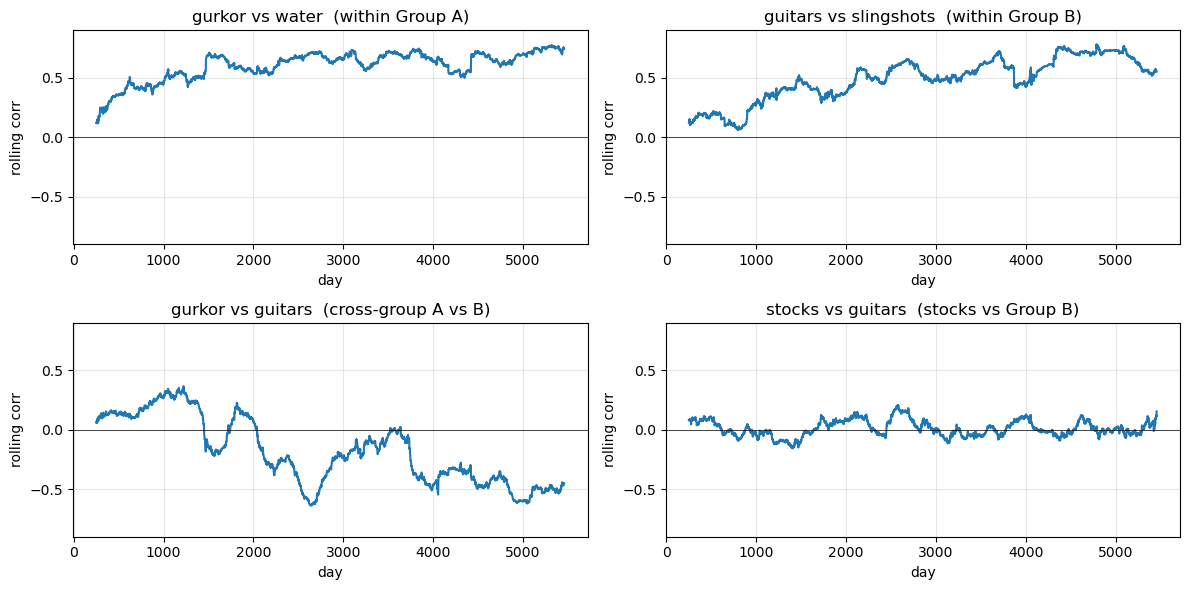

In [27]:
# Pairs that represent each "situation": within-group, cross-group, stocks-vs-rest
window = 252

pairs_to_check = [
    ('gurkor', 'water',       'within Group A'),
    ('guitars', 'slingshots', 'within Group B'),
    ('gurkor', 'guitars',     'cross-group A vs B'),
    ('stocks', 'guitars',     'stocks vs Group B'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes = axes.flatten()

for ax, (a, b, label) in zip(axes, pairs_to_check):
    rolling_corr = returns[a].rolling(window).corr(returns[b])
    ax.plot(rolling_corr.index, rolling_corr.values)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_ylim(-0.9, 0.9)
    ax.set_title(f"{a} vs {b}  ({label})")
    ax.set_xlabel("day")
    ax.set_ylabel("rolling corr")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
# Numerical summary of how stable each correlation is
summary = pd.DataFrame(columns=["mean", "std", "min", "max"])
for a, b, label in pairs_to_check:
    rc = returns[a].rolling(window).corr(returns[b]).dropna()
    summary.loc[f"{a} vs {b}"] = [rc.mean(), rc.std(), rc.min(), rc.max()]

print(summary.round(3))

                        mean    std    min    max
gurkor vs water        0.601  0.121  0.118  0.776
guitars vs slingshots  0.489  0.179  0.059  0.783
gurkor vs guitars     -0.184  0.277 -0.637  0.367
stocks vs guitars      0.011  0.067 -0.156  0.207


### What the rolling correlations show

* **Within Group A** (`gurkor` vs `water`): correlation stays positive across the whole sample (never drops below ~0.35). The group is stable.
* **Within Group B** (`guitars` vs `slingshots`): also stays positive, but the magnitude varies more (between ~0.10 and ~0.78).
* **Cross-group A vs B** (`gurkor` vs `guitars`): this is the **unstable** one. It swings between roughly -0.64 and +0.28 and crosses zero. The full-sample number (-0.24) hides a relationship that flips sign at times.
* **Stocks vs Group B** (`stocks` vs `guitars`): stays close to zero throughout (within ±0.21), confirming `stocks` is consistently independent.

**Takeaway for tasks 3 and 4:** the groups themselves are real and stable, but the *negative* correlation between Group A and Group B is not always there. Any strategy or model that depends on the sign of the A–B relationship needs to either use a time-varying correlation estimate (e.g. rolling window or DCC-GARCH) or be hedged against the periods when that correlation goes positive.